# Notebook 4 — Monthly Business Metrics Time Series

Simulates a realistic onboarding cohort over `growth.n_months` months.  Entity acquisition
follows one of two configurable growth models (set `growth.model` in `config.yaml`):

| `model` | Parameters | Monthly rate formula |
|---------|-----------|----------------------|
| `"linear"` | `start_rate`, `end_rate` | linearly interpolated from start→end |
| `"exponential"` | `initial_rate`, `monthly_rate` | `initial_rate × (1 + monthly_rate)^t` |

A `±variation` noise term is applied to each month's deterministic rate.

Each entity's days-to-first-traffic is drawn from the realistic mixture distribution:
99% Gamma(k, θ) + 1% point mass at 400 days (never-traffic).

At the **end of each month**, report the business metrics for all entities
who have started, based on how much time has elapsed since their start date.

**Metrics reported monthly:**
1. `# entities` — cumulative entities who have started
2. `# no traffic` — started but not yet achieved first traffic
3. `avg days` *(cumulative)* — mean days-to-traffic over all entities who have ever converted
4. `median days` *(cumulative)* — median days-to-traffic over all entities who have ever converted
5. `avg score` — mean( cohort_median / days_i ) across all traffic entities
6. `# laggards` — entities where cohort_median / days_i < 1 (took longer than median)
7. `# score > 1` — entities where cohort_median / days_i > 1 (faster than median)
8. `score > 1 ratio` — `# ref-cohort score > 1` / `ref-cohort size`, where the reference
   cohort is all entities who started in the month ~`median_days` ago.  Bounded [0, 1].
9. `spot mean days` — mean days-to-traffic for entities whose **first** traffic event falls
   *within this calendar month* only (not cumulative). Converges toward the true population
   mean as more cohorts mature.
10. `spot median days` — median days-to-traffic for the same monthly-converter population.

**Key insight to watch for:** Cumulative avg/median (metrics 3–4) start artificially low
because only fast entities have had enough elapsed time to convert in early months.
The spot estimates (9–10) show the same bias early on but converge differently: they reflect
the mix of fast recent starters and slow older starters converting in the same calendar month.

In [6]:
import sys
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Resolve project root regardless of where Jupyter was launched.
# Works from: misc-jupyter-notebooks/, time_to_traffic_metric_design/, or notebooks/
_cwd = Path(os.getcwd())
_PROJECT_ROOT = next(
    (p.resolve() for p in [_cwd, _cwd.parent, _cwd / 'time_to_traffic_metric_design']
     if (p / 'time_to_traffic_sim').is_dir()),
    None,
)
if _PROJECT_ROOT is None:
    raise RuntimeError(
        f"Cannot locate time_to_traffic_sim from {_cwd}. "
        "Launch Jupyter from misc-jupyter-notebooks/ or time_to_traffic_metric_design/."
    )
sys.path.insert(0, str(_PROJECT_ROOT))
OUTPUT_DIR = _PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

from time_to_traffic_sim.gamma_params import fit_gamma_params, describe_distribution

In [7]:
import yaml
with open(_PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

MODE_DAYS          = config['gamma']['mode_days']
MEDIAN_DAYS        = config['gamma']['median_days']
SEED               = config['simulation']['random_seed']
NEVER_TRAFFIC_FRAC = config['simulation']['never_traffic_fraction']
NEVER_TRAFFIC_DAYS = config['simulation']['never_traffic_days']

GROWTH_MODEL   = config['growth']['model']
N_MONTHS       = config['growth']['n_months']
DAYS_PER_MONTH = config['growth']['days_per_month']
VARIATION      = config['growth']['variation']

print(f'Config: mode={MODE_DAYS} d, median={MEDIAN_DAYS} d, '
      f'never-traffic={NEVER_TRAFFIC_FRAC:.0%} at {NEVER_TRAFFIC_DAYS:.0f} d, seed={SEED}')
print(f'Growth: model={GROWTH_MODEL!r}, n_months={N_MONTHS}, variation=±{VARIATION:.0%}')

Config: mode=7.0 d, median=45.0 d, never-traffic=1% at 400 d, seed=42
Growth: model='exponential', n_months=96, variation=±10%


In [8]:
k, theta = fit_gamma_params(mode_days=MODE_DAYS, median_days=MEDIAN_DAYS)
pop_stats = describe_distribution(k, theta)

# Deterministic monthly acquisition rate curve for the chosen growth model
_gc = config['growth']
if GROWTH_MODEL == 'linear':
    _lc = _gc['linear']
    base_rates = np.linspace(_lc['start_rate'], _lc['end_rate'], N_MONTHS)
    growth_label = f"linear {_lc['start_rate']}→{_lc['end_rate']} entities/mo"
elif GROWTH_MODEL == 'exponential':
    _ec = _gc['exponential']
    base_rates = _ec['initial_rate'] * (1 + _ec['monthly_rate']) ** np.arange(N_MONTHS)
    growth_label = f"exponential {_ec['initial_rate']} × (1+{_ec['monthly_rate']})^t"
else:
    raise ValueError(f"Unknown growth model: {GROWTH_MODEL!r}. Use 'linear' or 'exponential'.")

print(f'Gamma parameters: k={k:.4f}, θ={theta:.2f}')
print(f'Population mean: {pop_stats["mean"]:.1f} d   Population median: {pop_stats["median"]:.1f} d')
print(f'Never-traffic: {NEVER_TRAFFIC_FRAC:.0%} at {NEVER_TRAFFIC_DAYS:.0f} d')
print(f'Growth: {growth_label}')
print(f'Monthly rate range: [{base_rates.min():.1f}, {base_rates.max():.1f}]  (±{VARIATION:.0%} noise)')

Gamma parameters: k=1.1270, θ=55.10
Population mean: 62.1 d   Population median: 45.0 d
Never-traffic: 1% at 400 d
Growth: exponential 1000 × (1+-0.05)^t
Monthly rate range: [7.7, 1000.0]  (±10% noise)


## Monthly Cohort Simulation

Generate entity start dates (distributed across months according to the growth model) and days-to-first-traffic (from the mixture distribution). Then compute all 15 business metrics at each month-end checkpoint.

In [9]:
rng = np.random.default_rng(SEED)

# Apply ±VARIATION noise to the deterministic growth curve
monthly_counts = np.round(
    base_rates * rng.uniform(1 - VARIATION, 1 + VARIATION, size=N_MONTHS)
).astype(int)
n_actual = int(monthly_counts.sum())
print(f'Monthly count range: [{monthly_counts.min()}, {monthly_counts.max()}]  '
      f'({GROWTH_MODEL} growth, ±{VARIATION:.0%} noise)')
print(f'Total entities: {n_actual}')

# Assign each entity a random start day within their month
start_days_list = []
for m_idx, count in enumerate(monthly_counts):
    month_start = m_idx * DAYS_PER_MONTH + 1.0
    month_end   = (m_idx + 1) * DAYS_PER_MONTH
    start_days_list.append(rng.uniform(month_start, month_end, size=count))
start_days = np.sort(np.concatenate(start_days_list))

# Days to first traffic from realistic mixture distribution
raw_days = rng.gamma(shape=k, scale=theta, size=n_actual)
never_mask = rng.random(size=n_actual) < NEVER_TRAFFIC_FRAC
days_to_traffic = np.where(never_mask, NEVER_TRAFFIC_DAYS, raw_days)

print(f'Never-traffic entities in simulation: {never_mask.sum()} ({never_mask.mean():.1%})')

# Absolute calendar day when each entity first achieves traffic — used for spot estimates
traffic_day = start_days + days_to_traffic

# Population median used as the lookback window for the score>1 ratio
lookback = pop_stats['median']

# Compute monthly business metrics
records = []
for month in range(1, N_MONTHS + 1):
    end_day         = month * DAYS_PER_MONTH
    month_start_day = (month - 1) * DAYS_PER_MONTH

    # Entities who have started by end of this month
    started_mask = start_days <= end_day
    idx = np.where(started_mask)[0]
    n_started = len(idx)

    # Days elapsed since each entity's start
    elapsed = end_day - start_days[idx]

    # Achieved traffic: elapsed time >= their days_to_first_traffic
    achieved_mask = elapsed >= days_to_traffic[idx]
    n_traffic    = achieved_mask.sum()
    n_no_traffic = n_started - n_traffic

    # Reference cohort: entities who started in the month containing (end_day - median)
    ref_day = end_day - lookback
    if ref_day >= 1:
        ref_m    = int((ref_day - 1) // DAYS_PER_MONTH)
        rm_start = ref_m * DAYS_PER_MONTH + 1.0
        rm_end   = (ref_m + 1) * DAYS_PER_MONTH
        ref_cohort_idx = np.where(
            (start_days >= rm_start) & (start_days <= rm_end)
        )[0]
        n_ref_cohort = len(ref_cohort_idx)
    else:
        ref_cohort_idx = np.array([], dtype=int)
        n_ref_cohort   = 0

    # Spot estimates: entities whose first-traffic event falls within THIS calendar month
    spot_mask     = (traffic_day > month_start_day) & (traffic_day <= end_day)
    spot_days_arr = days_to_traffic[spot_mask]
    n_spot        = len(spot_days_arr)
    if n_spot > 0:
        spot_mean_val   = float(np.mean(spot_days_arr))
        spot_median_val = float(np.median(spot_days_arr))
    else:
        spot_mean_val = spot_median_val = float('nan')

    if n_traffic > 0:
        t_days     = days_to_traffic[idx[achieved_mask]]
        avg_days   = float(np.mean(t_days))
        med_days   = float(np.median(t_days))
        scores     = med_days / t_days
        avg_score  = float(np.mean(scores))
        n_laggards  = int((scores < 1).sum())
        n_score_gt1 = int((scores > 1).sum())

        if n_ref_cohort > 0:
            ref_elapsed  = end_day - start_days[ref_cohort_idx]
            ref_achieved = ref_elapsed >= days_to_traffic[ref_cohort_idx]
            ref_t_days   = days_to_traffic[ref_cohort_idx[ref_achieved]]
            n_ref_gt1 = int((med_days / ref_t_days > 1).sum()) if len(ref_t_days) > 0 else 0
        else:
            n_ref_gt1 = 0
    else:
        avg_days = med_days = avg_score = float('nan')
        n_laggards  = 0
        n_score_gt1 = 0
        n_ref_gt1   = 0

    score_gt1_ratio = n_ref_gt1 / n_ref_cohort if n_ref_cohort > 0 else float('nan')

    records.append({
        'month':           month,
        'new_entities':    int(monthly_counts[month - 1]),
        'n_entities':      n_started,
        'n_no_traffic':    n_no_traffic,
        'avg_days':        avg_days,
        'median_days':     med_days,
        'avg_score':       avg_score,
        'n_laggards':      n_laggards,
        'n_score_gt1':     n_score_gt1,
        'n_ref_cohort':    n_ref_cohort,
        'n_ref_gt1':       n_ref_gt1,
        'score_gt1_ratio': score_gt1_ratio,
        'n_spot':          n_spot,
        'spot_mean':       spot_mean_val,
        'spot_median':     spot_median_val,
    })

metrics = pd.DataFrame(records)
print(metrics.to_string(index=False))

Monthly count range: [8, 1055]  (exponential growth, ±10% noise)
Total entities: 20098
Never-traffic entities in simulation: 201 (1.0%)
 month  new_entities  n_entities  n_no_traffic  avg_days  median_days  avg_score  n_laggards  n_score_gt1  n_ref_cohort  n_ref_gt1  score_gt1_ratio  n_spot  spot_mean  spot_median
     1          1055        1055           886  9.345652     8.384713   3.338508          84           84             0          0              NaN     169   9.345652     8.384713
     2           938        1993          1347 18.496606    15.916179   3.268456         323          323          1055        193         0.182938     477  21.738768    20.214299
     3           967        2960          1616 26.314205    22.412467   3.229210         672          672           938        238         0.253731     698  33.549404    31.184376
     4           891        3851          1746 31.957009    26.947448   3.714767        1052         1052           967        319         0.329

## Business Metrics Time Series

Plot all 12 monthly metrics across the simulation period: entity volume and cumulative conversion timing (rows 1–2), health score behavior (row 3), laggard/leader counts and ref-cohort ratio (rows 4–5), and spot-estimate convergence (row 6).

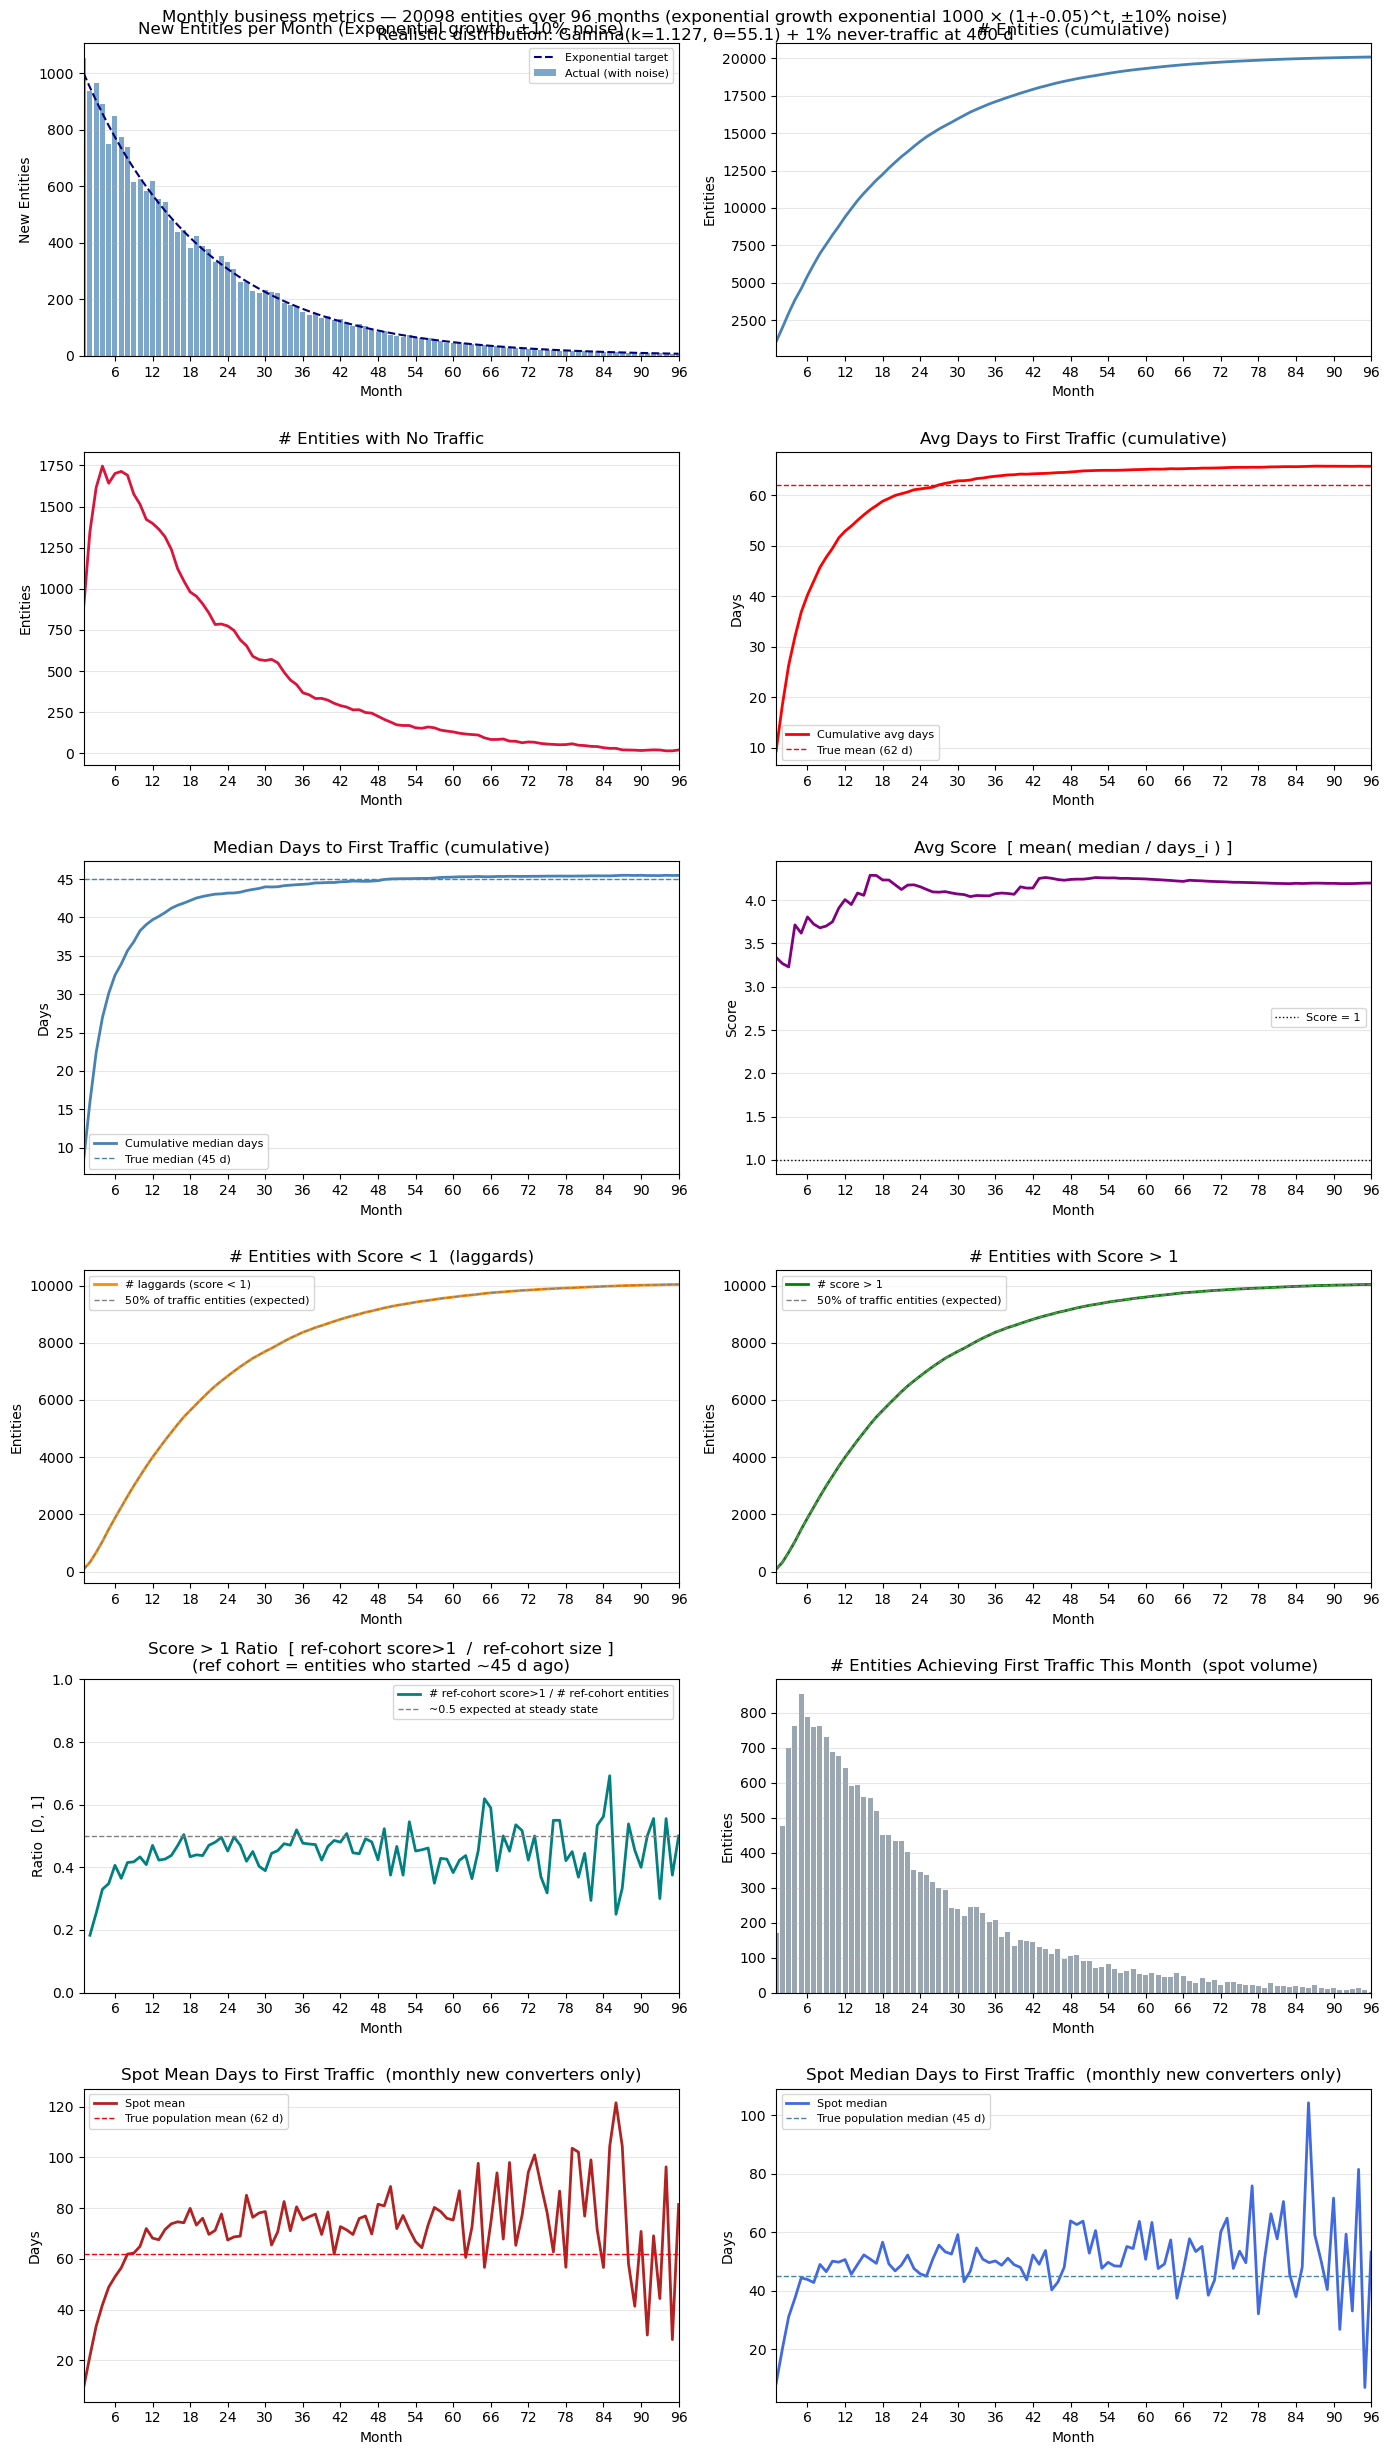

In [10]:
fig, axes = plt.subplots(6, 2, figsize=(14, 25))
months = metrics['month']

# 0,0 — new entities per month with growth curve overlay
ax = axes[0, 0]
ax.bar(months, metrics['new_entities'], color='steelblue', alpha=0.7, width=0.8, label='Actual (with noise)')
ax.plot(months, base_rates, color='navy', lw=1.5, ls='--', label=f'{GROWTH_MODEL.capitalize()} target')
ax.set_title(f'New Entities per Month ({GROWTH_MODEL.capitalize()} growth, ±{VARIATION:.0%} noise)')
ax.set_ylabel('New Entities')
ax.legend(fontsize=8)

# 0,1 — cumulative entities
ax = axes[0, 1]
ax.plot(months, metrics['n_entities'], color='steelblue', lw=2)
ax.set_title('# Entities (cumulative)')
ax.set_ylabel('Entities')

# 1,0 — # no traffic
ax = axes[1, 0]
ax.plot(months, metrics['n_no_traffic'], color='crimson', lw=2)
ax.set_title('# Entities with No Traffic')
ax.set_ylabel('Entities')

# 1,1 — cumulative avg days to first traffic
ax = axes[1, 1]
ax.plot(months, metrics['avg_days'], color='red', lw=2, label='Cumulative avg days')
ax.axhline(pop_stats['mean'], color='red', lw=1, ls='--',
           label=f'True mean ({pop_stats["mean"]:.0f} d)')
ax.set_title('Avg Days to First Traffic (cumulative)')
ax.set_ylabel('Days')
ax.legend(fontsize=8)

# 2,0 — cumulative median days to first traffic
ax = axes[2, 0]
ax.plot(months, metrics['median_days'], color='steelblue', lw=2, label='Cumulative median days')
ax.axhline(pop_stats['median'], color='steelblue', lw=1, ls='--',
           label=f'True median ({pop_stats["median"]:.0f} d)')
ax.set_title('Median Days to First Traffic (cumulative)')
ax.set_ylabel('Days')
ax.legend(fontsize=8)

# 2,1 — avg score (mean of cohort_median / days_i)
ax = axes[2, 1]
ax.plot(months, metrics['avg_score'], color='purple', lw=2)
ax.axhline(1.0, color='black', lw=1, ls=':', label='Score = 1')
ax.set_title('Avg Score  [ mean( median / days_i ) ]')
ax.set_ylabel('Score')
ax.legend(fontsize=8)

# 3,0 — # laggards (score < 1)
ax = axes[3, 0]
ax.plot(months, metrics['n_laggards'], color='darkorange', lw=2, label='# laggards (score < 1)')
ax.plot(months, metrics['n_entities'].sub(metrics['n_no_traffic']) * 0.5,
        color='grey', lw=1, ls='--', label='50% of traffic entities (expected)')
ax.set_title('# Entities with Score < 1  (laggards)')
ax.set_ylabel('Entities')
ax.legend(fontsize=8)

# 3,1 — # score > 1 (mirror of laggards)
ax = axes[3, 1]
ax.plot(months, metrics['n_score_gt1'], color='green', lw=2, label='# score > 1')
ax.plot(months, metrics['n_entities'].sub(metrics['n_no_traffic']) * 0.5,
        color='grey', lw=1, ls='--', label='50% of traffic entities (expected)')
ax.set_title('# Entities with Score > 1')
ax.set_ylabel('Entities')
ax.legend(fontsize=8)

# 4,0 — score>1 ratio (ref-cohort restricted)
ax = axes[4, 0]
ax.plot(months, metrics['score_gt1_ratio'], color='teal', lw=2,
        label='# ref-cohort score>1 / # ref-cohort entities')
ax.axhline(0.5, color='grey', lw=1, ls='--', label='~0.5 expected at steady state')
ax.set_ylim(0, 1)
ax.set_title(
    f'Score > 1 Ratio  [ ref-cohort score>1  /  ref-cohort size ]\n'
    f'(ref cohort = entities who started ~{pop_stats["median"]:.0f} d ago)'
)
ax.set_ylabel('Ratio  [0, 1]')
ax.legend(fontsize=8)

# 4,1 — # of entities starting to pass traffic this month (spot volume)
ax = axes[4, 1]
ax.bar(months, metrics['n_spot'], color='slategrey', alpha=0.7, width=0.8)
ax.set_title('# Entities Achieving First Traffic This Month  (spot volume)')
ax.set_ylabel('Entities')

# 5,0 — spot mean days to first traffic
ax = axes[5, 0]
ax.plot(months, metrics['spot_mean'], color='firebrick', lw=2, label='Spot mean')
ax.axhline(pop_stats['mean'], color='red', lw=1, ls='--',
           label=f'True population mean ({pop_stats["mean"]:.0f} d)')
ax.set_title('Spot Mean Days to First Traffic  (monthly new converters only)')
ax.set_ylabel('Days')
ax.legend(fontsize=8)

# 5,1 — spot median days to first traffic
ax = axes[5, 1]
ax.plot(months, metrics['spot_median'], color='royalblue', lw=2, label='Spot median')
ax.axhline(pop_stats['median'], color='steelblue', lw=1, ls='--',
           label=f'True population median ({pop_stats["median"]:.0f} d)')
ax.set_title('Spot Median Days to First Traffic  (monthly new converters only)')
ax.set_ylabel('Days')
ax.legend(fontsize=8)

for ax in axes.flatten():
    ax.set_xlabel('Month')
    ax.set_xlim(1, N_MONTHS)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(6))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Monthly business metrics — {n_actual} entities over {N_MONTHS} months '
    f'({GROWTH_MODEL} growth {growth_label}, ±{VARIATION:.0%} noise)\n'
    f'Realistic distribution: Gamma(k={k:.3f}, θ={theta:.1f}) + {NEVER_TRAFFIC_FRAC:.0%} never-traffic at {NEVER_TRAFFIC_DAYS:.0f} d',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_monthly_metrics.png', dpi=150)
plt.show()

## Snapshot Observations

Print a three-column snapshot (months 3, 12, 36) to highlight how metrics evolve from early survivorship bias through steady-state convergence toward true population values.

In [11]:
# Highlight key months for interpretation
early  = metrics[metrics['month'] == 3].iloc[0]
mid    = metrics[metrics['month'] == 12].iloc[0]
late   = metrics[metrics['month'] == 36].iloc[0]

print('Snapshot at selected months:')
print(f'{"":22s} {"Month 3":>12s} {"Month 12":>12s} {"Month 36":>12s}')
print(f'{"# entities":22s} {early.n_entities:>12.0f} {mid.n_entities:>12.0f} {late.n_entities:>12.0f}')
print(f'{"# no traffic":22s} {early.n_no_traffic:>12.0f} {mid.n_no_traffic:>12.0f} {late.n_no_traffic:>12.0f}')
print(f'{"avg days":22s} {early.avg_days:>12.1f} {mid.avg_days:>12.1f} {late.avg_days:>12.1f}')
print(f'{"median days":22s} {early.median_days:>12.1f} {mid.median_days:>12.1f} {late.median_days:>12.1f}')
print(f'{"avg score":22s} {early.avg_score:>12.3f} {mid.avg_score:>12.3f} {late.avg_score:>12.3f}')
print(f'{"# laggards":22s} {early.n_laggards:>12.0f} {mid.n_laggards:>12.0f} {late.n_laggards:>12.0f}')
print(f'{"# score > 1 (all)":22s} {early.n_score_gt1:>12.0f} {mid.n_score_gt1:>12.0f} {late.n_score_gt1:>12.0f}')
print(f'{"ref cohort size":22s} {early.n_ref_cohort:>12.0f} {mid.n_ref_cohort:>12.0f} {late.n_ref_cohort:>12.0f}')
print(f'{"# score>1 (ref cohort)":22s} {early.n_ref_gt1:>12.0f} {mid.n_ref_gt1:>12.0f} {late.n_ref_gt1:>12.0f}')
print(f'{"score>1 ratio":22s} {early.score_gt1_ratio:>12.3f} {mid.score_gt1_ratio:>12.3f} {late.score_gt1_ratio:>12.3f}')
print()
print(f'True population mean:   {pop_stats["mean"]:.1f} d')
print(f'True population median: {pop_stats["median"]:.1f} d')
print()
print('Observations:')
print('  • Early months show artificially LOW avg/median days — only fast entities')
print('    have had enough elapsed time to achieve traffic (survivorship selection bias).')
print('  • Both avg and median converge upward toward their population values as the')
print('    entity base matures and slower entities achieve traffic.')
print('  • # no-traffic peaks early then declines as long-tenured entities eventually')
print('    achieve traffic; the never-traffic entities (400 d) contribute a persistent floor.')
print('  • # laggards and # score>1 together account for all traffic entities (~50% each).')
print('  • score>1 ratio is bounded [0, 1]: numerator = ref-cohort entities with score>1,')
print('    denominator = all entities in that same ref cohort. At steady state it should')
print('    approach ~0.5 × (traffic conversion rate) as the ref cohort fully matures.')

Snapshot at selected months:
                            Month 3     Month 12     Month 36
# entities                     2960         9395        17105
# no traffic                   1616         1398          368
avg days                       26.3         52.9         63.8
median days                    22.4         39.7         44.3
avg score                     3.229        4.007        4.075
# laggards                      672         3998         8368
# score > 1 (all)               672         3998         8368
ref cohort size                 938          583          174
# score>1 (ref cohort)          238          274           83
score>1 ratio                 0.254        0.470        0.477

True population mean:   62.1 d
True population median: 45.0 d

Observations:
  • Early months show artificially LOW avg/median days — only fast entities
    have had enough elapsed time to achieve traffic (survivorship selection bias).
  • Both avg and median converge upward toward their

## Volume vs Conversion Speed: Correlation Analysis

Test whether months with higher entity volume predict faster or slower days-to-first-traffic. If no significant correlation exists, onboarding speed is independent of intake volume — a useful finding for capacity planning.

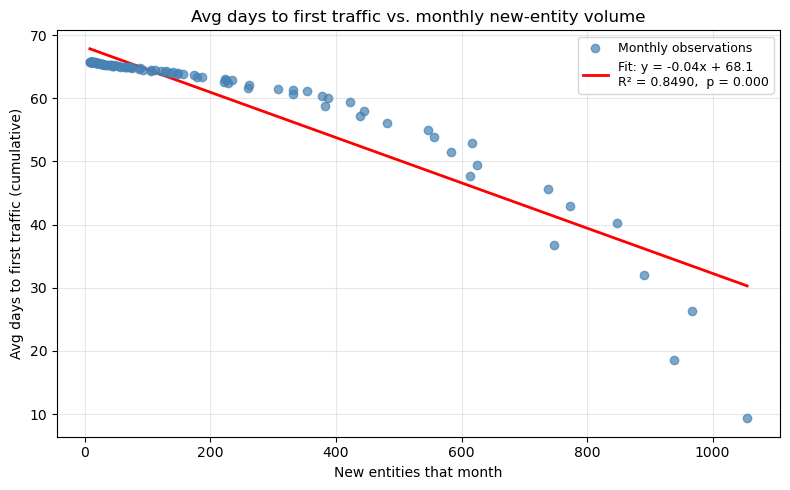

Slope:     -0.0359 days per additional entity
R²:        0.8490
p-value:   0.0000
Std error: 0.0016

Statistically significant correlation (p=0.0000): months with more new entities tend to have lower avg days.


In [12]:
from scipy import stats

# Drop months with no traffic data (first few months edge case)
corr_df = metrics.dropna(subset=['avg_days']).copy()

x = corr_df['new_entities'].to_numpy()
y = corr_df['avg_days'].to_numpy()

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
fit_x = np.linspace(x.min(), x.max(), 200)
fit_y = slope * fit_x + intercept

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='steelblue', alpha=0.7, zorder=3, label='Monthly observations')
ax.plot(fit_x, fit_y, color='red', lw=2,
        label=f'Fit: y = {slope:.2f}x + {intercept:.1f}\n'
              f'R² = {r_value**2:.4f},  p = {p_value:.3f}')

ax.set_xlabel('New entities that month')
ax.set_ylabel('Avg days to first traffic (cumulative)')
ax.set_title('Avg days to first traffic vs. monthly new-entity volume')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_correlation_volume_vs_days.png', dpi=150)
plt.show()

print(f'Slope:     {slope:.4f} days per additional entity')
print(f'R²:        {r_value**2:.4f}')
print(f'p-value:   {p_value:.4f}')
print(f'Std error: {std_err:.4f}')
print()
if p_value < 0.05:
    print(f'Statistically significant correlation (p={p_value:.4f}): months with more '
          f'new entities tend to have {"higher" if slope > 0 else "lower"} avg days.')
else:
    print(f'No statistically significant correlation (p={p_value:.4f}): monthly '
          f'onboarding volume does not predict avg days to first traffic.')

In [13]:
# ── Run simulation CLI or test suite from this notebook ──────────────────────
import subprocess

def run_simulation(config_path=None):
    """Run the full Monte Carlo simulation via bin/run_simulation.py."""
    cmd = [sys.executable, str(_PROJECT_ROOT / 'bin' / 'run_simulation.py'),
           '--config', str(config_path or _PROJECT_ROOT / 'config.yaml')]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(_PROJECT_ROOT))
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

def run_tests(verbose=True):
    """Run the project test suite with pytest."""
    cmd = [sys.executable, '-m', 'pytest', str(_PROJECT_ROOT / 'test')]
    if verbose:
        cmd.append('-v')
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(_PROJECT_ROOT))
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

# Uncomment to run:
# run_simulation()
# run_tests()